In [ ]:
!pip install keras-tuner
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
import numpy as np
import os
import shutil
import zipfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/MyDrive/RiceLeafsDisease.zip'

In [ ]:

from sklearn.model_selection import train_test_split


zip_file_path = '/content/drive/MyDrive/RiceLeafsDisease.zip'
extracted_dir = '/content/RiceLeafsDisease'
output_dir = '/content/organized_dataset'


with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_dir)


print("Extracted directory structure:")
for root, dirs, files in os.walk(extracted_dir):
    print("Root:", root)
    print("Directories:", dirs)
    print("Files:", files)
    print("-" * 40)

for split in ['train', 'validation', 'test']:
    for class_name in ['bacterial_leaf_blight', 'healthy', 'leaf_blast', 'leaf_scald']:
        os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)

images = []
labels = []

for class_name in ['bacterial_leaf_blight', 'healthy', 'leaf_blast', 'leaf_scald']:
    class_dir = None
    for root, dirs, files in os.walk(extracted_dir):
        if class_name in dirs:
            class_dir = os.path.join(root, class_name)
            break

    if class_dir is None:
        print(f"Warning: Directory for class '{class_name}' not found. Skipping...")
        continue

    for img in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img)
        if os.path.isfile(img_path):
            images.append(img_path)
            labels.append(class_name)

print(f"Total images found: {len(images)}")

if len(images) == 0:
    raise ValueError("No images found in the dataset. Please check the dataset structure.")

train_images, temp_images, train_labels, temp_labels = train_test_split(
    images, labels, test_size=0.3, stratify=labels, random_state=42
)
val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

def move_images(image_list, labels_list, split):
    for img, label in zip(image_list, labels_list):
        dest_dir = os.path.join(output_dir, split, label)
        shutil.copy(img, dest_dir)

move_images(train_images, train_labels, 'train')
move_images(val_images, val_labels, 'validation')
move_images(test_images, test_labels, 'test')

print("Data has been organized successfully.")
print(f"Train set: {len(train_images)} images")
print(f"Validation set: {len(val_images)} images")
print(f"Test set: {len(test_images)} images")


Extracted directory structure:
Root: /content/RiceLeafsDisease
Directories: ['RiceLeafsDisease']
Files: []
----------------------------------------
Root: /content/RiceLeafsDisease/RiceLeafsDisease
Directories: ['healthy', 'leaf_scald', 'leaf_blast', 'bacterial_leaf_blight']
Files: ['desktop.ini']
----------------------------------------
Root: /content/RiceLeafsDisease/RiceLeafsDisease/healthy
Directories: []
Files: ['healthy (282).jpg', 'healthy (278).jpg', 'healthy (99).jpg', 'healthy (45).jpg', 'healthy (298).jpg', 'healthy (103).jpg', 'healthy (154).jpg', 'healthy (181).jpg', 'healthy (190).jpg', 'healthy (171).jpg', 'healthy (140).jpg', 'healthy (97).jpg', 'healthy (146).jpg', 'healthy (288).jpg', 'healthy (323).jpg', 'healthy (101).jpg', 'healthy (57).jpg', 'healthy (223).jpg', 'healthy (117).jpg', 'healthy (287).jpg', 'healthy (11).jpg', 'healthy (65).jpg', 'healthy (168).jpg', 'healthy (277).jpg', 'healthy (209).jpg', 'healthy (71).jpg', 'healthy (107).jpg', 'healthy (27).jpg', 

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_dir = os.path.join(output_dir, 'train')
validation_dir = os.path.join(output_dir, 'validation')

datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)


test_dir = os.path.join(output_dir, 'test')
test_datagen = ImageDataGenerator(rescale=1.0/255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 1376 images belonging to 4 classes.
Found 295 images belonging to 4 classes.
Found 296 images belonging to 4 classes.


In [ ]:
import keras_tuner as kt

def build_model(hp):
    base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
    base_model.trainable = hp.Boolean("train_base_model", default=False)

    model = Sequential([
        base_model,
        Flatten(),
        Dense(hp.Int("units", min_value=64, max_value=256, step=32), activation='relu'),
        Dropout(hp.Float("dropout_rate", min_value=0.2, max_value=0.5, step=0.1)),
        Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer=hp.Choice("optimizer", values=["adam", "rmsprop", "sgd"]),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='my_tuner_results',
    project_name='rice_disease_tuning'
)

# Start the search
tuner.search(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    verbose=1
)

# Retrieve the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best Hyperparameters:")
print(f"Units: {best_hps.get('units')}")
print(f"Dropout Rate: {best_hps.get('dropout_rate')}")
print(f"Optimizer: {best_hps.get('optimizer')}")
print(f"Train Base Model: {best_hps.get('train_base_model')}")


Trial 10 Complete [00h 12m 31s]
val_accuracy: 0.8915254473686218

Best val_accuracy So Far: 0.9152542352676392
Total elapsed time: 02h 39m 09s
Best Hyperparameters:
Units: 256
Dropout Rate: 0.4
Optimizer: rmsprop
Train Base Model: False


In [ ]:
# Build the best model
best_model = tuner.hypermodel.build(best_hps)

history = best_model.fit(
    train_generator,
    epochs=20,  # You can increase this as needed
    validation_data=validation_generator
)

# Evaluate on test data
test_loss, test_accuracy = best_model.evaluate(test_generator)
print(f"Test Accuracy after tuning: {test_accuracy * 100:.2f}%")

# Save the tuned model
best_model.save('/content/rice_disease_model_tuned.h5')
print("Tuned model saved as rice_disease_model_tuned.h5")


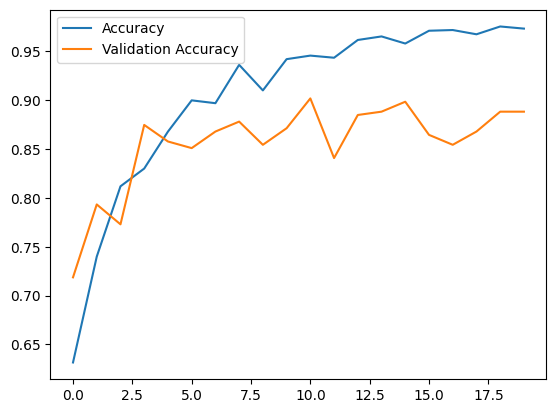

In [ ]:


plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()


In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


In [ ]:
!pip install seaborn
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report # Import confusion_matrix and classification_report

y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=1)

conf_matrix = confusion_matrix(y_true, y_pred)  # Now confusion_matrix is defined
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(test_generator.class_indices.keys()),
            yticklabels=list(test_generator.class_indices.keys()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

In [ ]:
# Save the trained model
model.save('/content/rice_disease_model.h5')
print("Model saved as rice_disease_model.h5")


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = '/content/organized_dataset/test/bacterial_leaf_blight/Bacterial_leaf_Blight (613).jpg'  # Replace with the path to your image
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)


predictions = model.predict(img_array)
class_index = np.argmax(predictions)
class_labels = list(train_generator.class_indices.keys())
predicted_class = class_labels[class_index]

print(f"Predicted class: {predicted_class}")


In [ ]:
from tensorflow.keras.preprocessing import image

def visualize_prediction(img_path, model, class_labels, true_label=None):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(150, 150))  # Match your model's input size
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)


    # Make prediction
    prediction = model.predict(img_array)
    predicted_class = class_labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100


    plt.imshow(image.load_img(img_path))
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)\n"
              f"True: {true_label if true_label else 'Unknown'}", fontsize=12)
    plt.show()




In [ ]:
# Example usage
# Example usage
img_path = '/content/organized_dataset/test/bacterial_leaf_blight/Bacterial_leaf_Blight (645).jpg'
true_label = 'Bacterial_leaf_Blight'  # Set the true label of the image
visualize_prediction(img_path, model, list(train_generator.class_indices.keys()), true_label)